In [1]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
files = sorted(
    [file.name for file in gtfs_path.iterdir()]
)

files

NameError: name 'gtfs_path' is not defined

In [ ]:
calendar_dates = pd.read_csv(
    gtfs_path / "calendar_dates.txt"
)

print("Shape:", calendar_dates.shape)
print("Columns:", calendar_dates.columns.tolist())

calendar_dates.head(10)

Shape: (5060, 3)
Columns: ['service_id', 'date', 'exception_type']


,service_id,date,exception_type
0,10-Holiday1-1-2026_4-0000001,20260907,1
1,10-Holiday1-1-2026_4-0000001,20261012,1
2,10-Saturday-1-2026_4-0000010,20260912,1
3,10-Saturday-1-2026_4-0000010,20260919,1
4,10-Saturday-1-2026_4-0000010,20260926,1
5,10-Saturday-1-2026_4-0000010,20261003,1
6,10-Saturday-1-2026_4-0000010,20261010,1
7,10-Saturday-1-2026_4-0000010,20261017,1
8,10-Saturday-1-2026_4-0000010,20261024,1
9,10-Saturday-1-2026_4-0000010,20261031,1


In [ ]:
calendar_dates["date"] = pd.to_datetime(
    calendar_dates["date"].astype(str),
    format="%Y%m%d"
)

print(
    "First date:",
    calendar_dates["date"].min()
)

print(
    "Last date:",
    calendar_dates["date"].max()
)

print(
    calendar_dates["exception_type"].value_counts()
)

First date: 2026-09-07 00:00:00
Last date: 2026-12-20 00:00:00
exception_type
1    5060
Name: count, dtype: int64


In [ ]:
services_by_date = (
    calendar_dates[
        calendar_dates["exception_type"] == 1
    ]
    .groupby("date")["service_id"]
    .nunique()
)

services_by_date.head(15)

date
2026-09-07    31
2026-09-08    51
2026-09-09    51
2026-09-10    52
2026-09-11    52
2026-09-12    43
2026-09-13    40
2026-09-14    51
2026-09-15    51
2026-09-16    51
2026-09-17    52
2026-09-18    52
2026-09-19    43
2026-09-20    40
2026-09-21    51
Name: service_id, dtype: int64

In [ ]:
service_calendar_summary = (
    services_by_date
    .reset_index(name="active_services")
)

service_calendar_summary["day_of_week"] = (
    service_calendar_summary["date"].dt.day_name()
)

service_calendar_summary.head(15)

,date,active_services,day_of_week
0,2026-09-07,31,Monday
1,2026-09-08,51,Tuesday
2,2026-09-09,51,Wednesday
3,2026-09-10,52,Thursday
4,2026-09-11,52,Friday
5,2026-09-12,43,Saturday
6,2026-09-13,40,Sunday
7,2026-09-14,51,Monday
8,2026-09-15,51,Tuesday
9,2026-09-16,51,Wednesday


In [ ]:
analysis_date = pd.Timestamp("2026-09-09")

active_services = calendar_dates[
    (calendar_dates["date"] == analysis_date) &
    (calendar_dates["exception_type"] == 1)
]["service_id"].unique()

print("Analysis date:", analysis_date.date())
print("Day:", analysis_date.day_name())
print("Active services:", len(active_services))

Analysis date: 2026-09-09
Day: Wednesday
Active services: 51


In [ ]:
weekday_trips = trips[
    trips["service_id"].isin(active_services)
].copy()

print("All trips:", len(trips))
print("Trips on analysis date:", len(weekday_trips))

All trips: 10766
Trips on analysis date: 4155


In [ ]:
print(
    "Unique active service IDs in filtered trips:",
    weekday_trips["service_id"].nunique()
)

print(
    "Unique routes:",
    weekday_trips["route_id"].nunique()
)

Unique active service IDs in filtered trips: 51
Unique routes: 51


In [ ]:
weekday_stop_times = stop_times.merge(
    weekday_trips[
        [
            "trip_id",
            "route_id",
            "service_id"
        ]
    ],
    on="trip_id",
    how="inner"
)

print("Weekday stop-time records:", len(weekday_stop_times))

weekday_stop_times.head()

Weekday stop-time records: 118520


,trip_id,arrival_time,departure_time,stop_id,stop_sequence,pickup_type,drop_off_type,route_id,service_id
0,4222123,15:45:00,15:45:00,3489,1,0,0,10,10-Weekday-1-2026_4-1111100
1,4222123,15:47:00,15:47:00,1697,2,0,0,10,10-Weekday-1-2026_4-1111100
2,4222123,15:49:00,15:49:00,1698,3,0,0,10,10-Weekday-1-2026_4-1111100
3,4222123,15:50:00,15:50:00,1699,4,0,0,10,10-Weekday-1-2026_4-1111100
4,4222123,15:50:00,15:50:00,1700,5,0,0,10,10-Weekday-1-2026_4-1111100


In [ ]:
stop_service = (
    weekday_stop_times
    .groupby("stop_id")
    .agg(
        daily_stop_events=("trip_id", "count"),
        unique_trips=("trip_id", "nunique"),
        unique_routes=("route_id", "nunique")
    )
    .reset_index()
)

stop_service.head(10)

,stop_id,daily_stop_events,unique_trips,unique_routes
0,1000,247,247,5
1,1001,38,38,1
2,1002,38,38,1
3,1003,38,38,1
4,1004,38,38,1
5,1006,38,38,1
6,1011,141,141,4
7,1012,38,38,1
8,1013,38,38,1
9,1014,76,76,2


In [ ]:
stop_service["daily_stop_events"].describe()

count    2242.000000
mean       52.863515
std        39.916480
min         1.000000
25%        34.000000
50%        37.000000
75%        67.000000
max       785.000000
Name: daily_stop_events, dtype: float64

In [ ]:
stop_service.sort_values(
    "daily_stop_events",
    ascending=False
).head(15)

,stop_id,daily_stop_events,unique_trips,unique_routes
537,1732,785,785,8
1682,3641,356,356,8
535,1728,355,355,8
42,1065,274,274,4
538,1734,265,265,6
536,1731,265,265,6
43,1066,254,254,4
647,1907,248,248,3
0,1000,247,247,5
1221,2785,246,246,4


In [ ]:
stops = pd.read_csv(
    gtfs_path / "stops.txt"
)

print(stops.shape)
print(stops.columns.tolist())

(2260, 12)
['stop_id', 'stop_code', 'stop_name', 'stop_desc', 'stop_lat', 'stop_lon', 'zone_id', 'stop_url', 'location_type', 'parent_station', 'wheelchair_boarding', 'platform_code']


In [ ]:
stop_service["stop_id"] = stop_service["stop_id"].astype(str)
stops["stop_id"] = stops["stop_id"].astype(str)

In [ ]:
print(stop_service["stop_id"].dtype)
print(stops["stop_id"].dtype)

str
str


In [ ]:
stop_service_named = stop_service.merge(
    stops[
        [
            "stop_id",
            "stop_name",
            "stop_lat",
            "stop_lon",
            "location_type",
            "parent_station"
        ]
    ],
    on="stop_id",
    how="left"
)

In [ ]:
print("Rows:", len(stop_service_named))
print(
    "Missing stop names:",
    stop_service_named["stop_name"].isna().sum()
)

Rows: 2242
Missing stop names: 0


In [ ]:
top15_service = (
    stop_service_named
    .sort_values(
        "daily_stop_events",
        ascending=False
    )
    .head(15)
)

top15_service[
    [
        "stop_id",
        "stop_name",
        "daily_stop_events",
        "unique_routes",
        "location_type",
        "parent_station"
    ]
]

,stop_id,stop_name,daily_stop_events,unique_routes,location_type,parent_station
537,1732,Conestoga College Doon Campus - Door 3,785,8,0,place_CCD
1682,3641,Conestoga College Blvd. / Homer Watson,356,8,0,NaN
535,1728,Conestoga College Blvd. / Homer Watson,355,8,0,NaN
42,1065,Cambridge Centre Station,274,4,0,place_CBC
538,1734,Doon Valley / Orchard Mill,265,6,0,NaN
536,1731,Conestoga College Doon Campus - Recreation Centre,265,6,0,NaN
43,1066,Cambridge Centre Station,254,4,0,place_CBC
647,1907,Waterloo Public Square Station,248,3,0,NaN
0,1000,Frederick Station (Frederick / King),247,5,0,NaN
1221,2785,University Ave. / King,246,4,0,place_KUN


In [ ]:
weekday_stop_times["departure_hour"] = (
    weekday_stop_times["departure_time"]
    .str.split(":")
    .str[0]
    .astype(int)
)

In [ ]:
weekday_stop_times[
    ["departure_time", "departure_hour"]
].head(10)

,departure_time,departure_hour
0,15:45:00,15
1,15:47:00,15
2,15:49:00,15
3,15:50:00,15
4,15:50:00,15
5,15:51:00,15
6,15:54:00,15
7,15:55:00,15
8,15:56:00,15
9,15:57:00,15


In [ ]:
print(
    "Earliest hour:",
    weekday_stop_times["departure_hour"].min()
)

print(
    "Latest hour:",
    weekday_stop_times["departure_hour"].max()
)

Earliest hour: 4
Latest hour: 25


In [ ]:
stop_1732 = weekday_stop_times[
    weekday_stop_times["stop_id"].astype(str) == "1732"
].copy()

print("Records:", len(stop_1732))

stop_1732[
    [
        "trip_id",
        "route_id",
        "arrival_time",
        "departure_time"
    ]
].head(20)

Records: 785


,trip_id,route_id,arrival_time,departure_time
19,4222123,10,16:10:00,16:10:00
44,4222124,10,06:53:00,06:53:00
69,4222125,10,14:23:00,14:23:00
94,4222126,10,13:23:00,13:23:00
119,4222127,10,11:53:00,11:53:00
144,4222128,10,17:56:00,17:56:00
164,4222129,10,17:40:00,17:40:00
189,4222130,10,17:26:00,17:26:00
209,4222131,10,17:10:00,17:10:00
234,4222132,10,16:56:00,16:56:00


In [ ]:
stop_1732_by_hour = (
    stop_1732
    .groupby("departure_hour")
    .size()
    .reset_index(name="scheduled_events")
)

stop_1732_by_hour

,departure_hour,scheduled_events
0,5,4
1,6,25
2,7,51
3,8,51
4,9,52
5,10,49
6,11,48
7,12,48
8,13,48
9,14,49


In [ ]:
stop_1732_by_route = (
    stop_1732
    .groupby("route_id")
    .size()
    .sort_values(ascending=False)
)

stop_1732_by_route

route_id
201    187
16     132
10     120
61     114
203     68
36      65
57      65
76      34
dtype: int64

In [ ]:
daytime_stop_times = weekday_stop_times[
    (weekday_stop_times["departure_hour"] >= 7) &
    (weekday_stop_times["departure_hour"] < 19)
].copy()

print(
    "Daytime stop events:",
    len(daytime_stop_times)
)

Daytime stop events: 83190


In [ ]:
daytime_frequency = (
    daytime_stop_times
    .groupby("stop_id")
    .agg(
        daytime_events=("trip_id", "count"),
        unique_routes=("route_id", "nunique")
    )
    .reset_index()
)

In [ ]:
daytime_frequency["stop_id"] = (
    daytime_frequency["stop_id"].astype(str)
)

In [ ]:
daytime_frequency["events_per_hour"] = (
    daytime_frequency["daytime_events"] / 12
)

In [ ]:
daytime_frequency = daytime_frequency.merge(
    stops[
        [
            "stop_id",
            "stop_name",
            "stop_lat",
            "stop_lon",
            "location_type",
            "parent_station"
        ]
    ],
    on="stop_id",
    how="left"
)

In [ ]:
print(
    "Stops with daytime service:",
    len(daytime_frequency)
)

print(
    "Missing stop names:",
    daytime_frequency["stop_name"].isna().sum()
)

print(
    daytime_frequency["events_per_hour"].describe()
)

Stops with daytime service: 2241
Missing stop names: 0
count    2241.000000
mean        3.093485
std         2.441389
min         0.083333
25%         2.000000
50%         2.000000
75%         4.000000
max        49.916667
Name: events_per_hour, dtype: float64


In [ ]:
daytime_frequency[
    [
        "stop_id",
        "stop_name",
        "daytime_events",
        "events_per_hour",
        "unique_routes"
    ]
].sort_values(
    "events_per_hour",
    ascending=False
).head(15)

,stop_id,stop_name,daytime_events,events_per_hour,unique_routes
536,1732,Conestoga College Doon Campus - Door 3,599,49.916667,8
1681,3641,Conestoga College Blvd. / Homer Watson,276,23.000000,8
534,1728,Conestoga College Blvd. / Homer Watson,273,22.750000,8
535,1731,Conestoga College Doon Campus - Recreation Centre,205,17.083333,6
537,1734,Doon Valley / Orchard Mill,204,17.000000,6
42,1065,Cambridge Centre Station,192,16.000000,4
1220,2785,University Ave. / King,178,14.833333,4
43,1066,Cambridge Centre Station,170,14.166667,4
630,1879,Kitchener City Hall Station,169,14.083333,4
345,1474,Central Station,169,14.083333,6


In [ ]:
frequency_gdf = gpd.GeoDataFrame(
    daytime_frequency,
    geometry=gpd.points_from_xy(
        daytime_frequency["stop_lon"],
        daytime_frequency["stop_lat"]
    ),
    crs="EPSG:4326"
)

print(frequency_gdf.crs)
print(frequency_gdf.shape)
frequency_gdf.head()

EPSG:4326
(2241, 10)


,stop_id,daytime_events,unique_routes,events_per_hour,stop_name,stop_lat,stop_lon,location_type,parent_station,geometry
0,1000,168,5,14.0,Frederick Station (Frederick / King),43.449674,-80.487209,0,NaN,POINT (-80.48721 43.44967)
1,1001,24,1,2.0,Frederick / Region Of Waterloo Headquarters,43.452334,-80.484195,0,NaN,POINT (-80.4842 43.45233)
2,1002,24,1,2.0,Frederick / Otto,43.453004,-80.482917,0,NaN,POINT (-80.48292 43.453)
3,1003,24,1,2.0,Frederick / Samuel,43.454834,-80.479514,0,NaN,POINT (-80.47951 43.45483)
4,1004,24,1,2.0,Frederick / Merner,43.456218,-80.476907,0,NaN,POINT (-80.47691 43.45622)


In [ ]:
frequency_projected = frequency_gdf.to_crs(
    "EPSG:26917"
)

print(frequency_projected.crs)

EPSG:26917


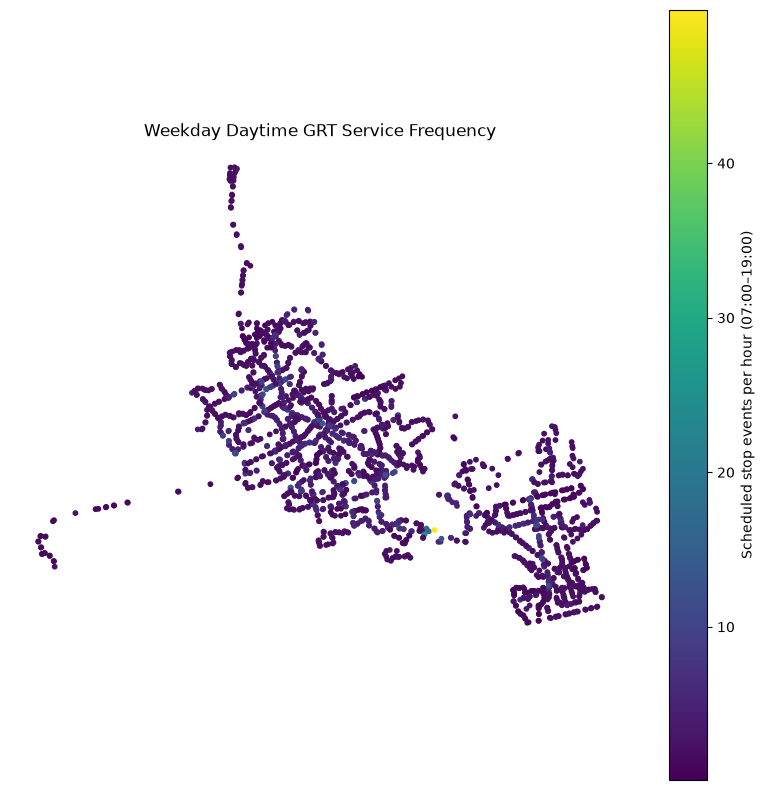

In [ ]:
fig, ax = plt.subplots(figsize=(10, 10))

frequency_projected.plot(
    ax=ax,
    column="events_per_hour",
    cmap="viridis",
    markersize=10,
    legend=True,
    legend_kwds={
        "label": "Scheduled stop events per hour (07:00–19:00)"
    }
)

ax.set_title(
    "Weekday Daytime GRT Service Frequency"
)

ax.set_axis_off()

plt.show()

In [ ]:
processed_path = Path("../data/processed")

da_accessibility = gpd.read_file(
    processed_path / "waterloo_accessibility.gpkg",
    layer="da_accessibility"
)

print(da_accessibility.shape)
print(da_accessibility.crs)

(766, 18)
EPSG:26917


In [ ]:
print("DA CRS:", da_accessibility.crs)
print("Frequency CRS:", frequency_projected.crs)

DA CRS: EPSG:26917
Frequency CRS: EPSG:26917


In [ ]:
stops_with_da = gpd.sjoin(
    frequency_projected,
    da_accessibility[
        [
            "DAUID",
            "FullName",
            "geometry"
        ]
    ],
    how="inner",
    predicate="within"
)

print("Stops assigned to a DA:", len(stops_with_da))
print("Unique DAs with daytime service stops:", stops_with_da["DAUID"].nunique())

Stops assigned to a DA: 2241
Unique DAs with daytime service stops: 578


In [ ]:
da_frequency = (
    stops_with_da
    .groupby("DAUID")
    .agg(
        stop_count=("stop_id", "count"),
        mean_events_per_hour=("events_per_hour", "mean"),
        median_events_per_hour=("events_per_hour", "median"),
        max_events_per_hour=("events_per_hour", "max"),
        total_events_per_hour=("events_per_hour", "sum")
    )
    .reset_index()
)

da_frequency.head()

,DAUID,stop_count,mean_events_per_hour,median_events_per_hour,max_events_per_hour,total_events_per_hour
0,35300003,1,2.0,2.0,2.0,2.0
1,35300005,2,3.0,3.0,4.0,6.0
2,35300006,3,2.0,2.0,2.0,6.0
3,35300008,4,2.0,2.0,2.0,8.0
4,35300009,2,2.0,2.0,2.0,4.0


In [ ]:
da_frequency[
    [
        "stop_count",
        "mean_events_per_hour",
        "median_events_per_hour",
        "max_events_per_hour"
    ]
].describe()

,stop_count,mean_events_per_hour,median_events_per_hour,max_events_per_hour
count,578.000000,578.000000,578.000000,578.000000
mean,3.877163,2.879639,2.724481,3.895617
std,5.476953,1.415110,1.363170,3.352999
min,1.000000,0.979167,0.750000,1.000000
25%,1.000000,2.000000,2.000000,2.000000
50%,2.000000,2.083333,2.000000,2.458333
75%,4.000000,3.862778,3.895833,4.687500
max,75.000000,11.900000,10.750000,49.916667


In [ ]:
da_frequency.sort_values(
    "mean_events_per_hour",
    ascending=False
).head(15)

,DAUID,stop_count,mean_events_per_hour,median_events_per_hour,max_events_per_hour,total_events_per_hour
271,35300473,10,11.900000,2.000000,49.916667,119.000000
407,35300719,2,10.750000,10.750000,13.166667,21.500000
222,35300396,7,8.154762,6.166667,14.000000,57.083333
73,35300131,2,7.916667,7.916667,9.833333,15.833333
101,35300165,1,7.833333,7.833333,7.833333,7.833333
275,35300480,3,7.138889,6.750000,8.833333,21.416667
171,35300298,8,7.010417,6.041667,14.833333,56.083333
169,35300296,11,6.909091,7.833333,13.083333,76.000000
14,35300039,3,6.666667,5.833333,10.000000,20.000000
212,35300381,11,6.643939,3.916667,14.083333,73.083333


In [ ]:
frequency_400 = frequency_projected[
    [
        "stop_id",
        "stop_name",
        "events_per_hour",
        "unique_routes",
        "geometry"
    ]
].copy()

frequency_400["geometry"] = (
    frequency_400.geometry.buffer(400)
)

frequency_400.head()

,stop_id,stop_name,events_per_hour,unique_routes,geometry
0,1000,Frederick Station (Frederick / King),14.0,5,"POLYGON ((541890.691 4810879.988, 541888.765 4..."
1,1001,Frederick / Region Of Waterloo Headquarters,2.0,1,"POLYGON ((542132.73 4811176.906, 542130.804 48..."
2,1002,Frederick / Otto,2.0,1,"POLYGON ((542235.669 4811251.955, 542233.743 4..."
3,1003,Frederick / Samuel,2.0,1,"POLYGON ((542509.726 4811456.905, 542507.8 481..."
4,1004,Frederick / Merner,2.0,1,"POLYGON ((542719.679 4811611.93, 542717.753 48..."


In [ ]:
print(frequency_400.crs)
print(frequency_400.shape)

EPSG:26917
(2241, 5)


In [ ]:
frequency_400.geometry.geom_type.value_counts()

Polygon    2241
Name: count, dtype: int64

In [ ]:
def classify_service(x):
    if x < 2:
        return "Low"
    elif x <= 4:
        return "Moderate"
    else:
        return "High"

frequency_projected["service_level"] = (
    frequency_projected["events_per_hour"]
    .apply(classify_service)
)

In [ ]:
frequency_projected[
    "service_level"
].value_counts()

service_level
Moderate    1461
High         400
Low          380
Name: count, dtype: int64

In [ ]:
service_level_summary = (
    frequency_projected["service_level"]
    .value_counts()
    .rename_axis("service_level")
    .reset_index(name="stops")
)

service_level_summary["percent"] = (
    service_level_summary["stops"]
    / service_level_summary["stops"].sum()
    * 100
)

service_level_summary

,service_level,stops,percent
0,Moderate,1461,65.194110
1,High,400,17.849174
2,Low,380,16.956716


In [ ]:
high_frequency_stops = frequency_projected[
    frequency_projected["service_level"] == "High"
].copy()

print("High-frequency stops:", len(high_frequency_stops))

High-frequency stops: 400


In [ ]:
high_400 = high_frequency_stops.copy()

high_400["geometry"] = high_400.geometry.buffer(400)

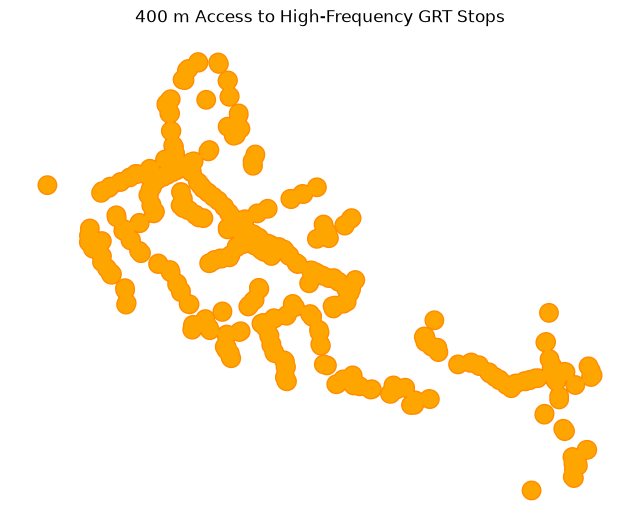

In [ ]:
high_400_union = high_400.geometry.union_all()

high_access_400 = gpd.GeoDataFrame(
    geometry=[high_400_union],
    crs=high_400.crs
)

high_access_400.plot(
    figsize=(8, 8),
    facecolor="orange",
    edgecolor="darkorange"
)

plt.title("400 m Access to High-Frequency GRT Stops")
plt.axis("off")
plt.show()

In [ ]:
da_accessibility

,DAUID,DGUID,LANDAREA,PRUID,Population,da_area,access_400_area,access_400_ratio,pop_access_400,access_800_area,access_800_ratio,pop_access_800,Pct_Access_400,Pct_Access_800,Pop_Beyond_800,FullName,Pct_Beyond_800,geometry
0,35300742,2021S051235300742,19.8582,35,542.0,2.067209e+07,0.000000,0.000000,0.00000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,5.420000e+02,Township of Woolwich,1.000000e+02,"POLYGON ((539891.695 4832762.944, 539908.692 4..."
1,35300743,2021S051235300743,33.7717,35,502.0,3.401332e+07,0.000000,0.000000,0.00000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,5.020000e+02,Township of Woolwich,1.000000e+02,"POLYGON ((540324.706 4832894.833, 540058.573 4..."
2,35300744,2021S051235300744,9.6519,35,415.0,9.908855e+06,0.000000,0.000000,0.00000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,4.150000e+02,Township of Woolwich,1.000000e+02,"POLYGON ((542065.69 4826395.948, 541891.695 48..."
3,35300745,2021S051235300745,27.1355,35,682.0,2.724843e+07,0.000000,0.000000,0.00000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,6.820000e+02,Township of Woolwich,1.000000e+02,"POLYGON ((547685.679 4825718.286, 547661.814 4..."
4,35300746,2021S051235300746,5.1751,35,560.0,5.381499e+06,0.000000,0.000000,0.00000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,5.600000e+02,Township of Woolwich,1.000000e+02,"POLYGON ((542811.425 4822377.365, 542811.692 4..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
761,35301056,2021S051235301056,0.0481,35,233.0,4.804305e+04,48043.048501,1.000000,233.00000,4.804305e+04,1.000000,233.000000,100.000000,100.000000,-5.684342e-14,City of Kitchener,-2.842171e-14,"POLYGON ((543811.612 4807736.28, 543854.696 48..."
762,35301057,2021S051235301057,0.5205,35,2447.0,5.200685e+05,520068.486809,1.000000,2447.00000,5.200685e+05,1.000000,2447.000000,100.000000,100.000000,4.547474e-13,City of Kitchener,1.421085e-14,"POLYGON ((545400.692 4807807.942, 545443.694 4..."
763,35301049,2021S051235301049,2.2263,35,1022.0,2.576927e+06,789765.263298,0.306476,313.21801,1.602074e+06,0.621699,635.376538,30.647555,62.169916,3.866235e+02,City of Cambridge,3.783008e+01,"POLYGON ((559191.7 4803987.945, 559111.7 48038..."
764,35301050,2021S051235301050,0.1040,35,688.0,1.084432e+05,108443.246771,1.000000,688.00000,1.084432e+05,1.000000,688.000000,100.000000,100.000000,1.136868e-13,City of Cambridge,2.842171e-14,"POLYGON ((557895.701 4804309.941, 557885.7 480..."


In [ ]:
da_high_access = da_accessibility[
    [
        "DAUID",
        "FullName",
        "Population",
        "geometry"
    ]
].copy()

da_high_access["da_area"] = (
    da_high_access.geometry.area
)

In [ ]:
high_intersection = gpd.overlay(
    da_high_access,
    high_access_400,
    how="intersection"
)

In [ ]:
high_intersection["high_400_area"] = (
    high_intersection.geometry.area
)

In [ ]:
high_intersection["high_400_ratio"] = (
    high_intersection["high_400_area"]
    / high_intersection["da_area"]
)

In [ ]:
high_intersection["high_400_ratio"] = (
    high_intersection["high_400_ratio"]
    .clip(0, 1)
)

In [ ]:
high_intersection["Pop_High_Access_400"] = (
    high_intersection["Population"]
    * high_intersection["high_400_ratio"]
)

In [ ]:
high_population_by_da = (
    high_intersection
    .groupby("DAUID")["Pop_High_Access_400"]
    .sum()
    .reset_index()
)

da_high_access = da_high_access.merge(
    high_population_by_da,
    on="DAUID",
    how="left"
)

da_high_access["Pop_High_Access_400"] = (
    da_high_access["Pop_High_Access_400"]
    .fillna(0)
)

In [ ]:
total_population = da_high_access["Population"].sum()

total_high_400 = (
    da_high_access["Pop_High_Access_400"].sum()
)

pct_high_400 = (
    total_high_400
    / total_population
    * 100
)

print(f"Total population: {total_population:,.0f}")
print(
    f"Estimated population within 400 m of a high-frequency stop: "
    f"{total_high_400:,.0f}"
)
print(
    f"Estimated share within 400 m of a high-frequency stop: "
    f"{pct_high_400:.1f}%"
)

Total population: 587,165
Estimated population within 400 m of a high-frequency stop: 164,777
Estimated share within 400 m of a high-frequency stop: 28.1%


In [ ]:
municipality_high_frequency = (
    da_high_access
    .groupby("FullName")
    .agg(
        Population=("Population", "sum"),
        Pop_High_Access_400=("Pop_High_Access_400", "sum")
    )
    .reset_index()
)

municipality_high_frequency["Pct_High_Frequency_400"] = (
    municipality_high_frequency["Pop_High_Access_400"]
    / municipality_high_frequency["Population"]
    * 100
)

municipality_high_frequency[
    [
        "FullName",
        "Population",
        "Pop_High_Access_400",
        "Pct_High_Frequency_400"
    ]
].sort_values(
    "Pct_High_Frequency_400",
    ascending=False
)

,FullName,Population,Pop_High_Access_400,Pct_High_Frequency_400
2,City of Waterloo,121436.0,52133.980305,42.931240
1,City of Kitchener,256885.0,92165.390174,35.878074
0,City of Cambridge,138479.0,20461.683812,14.776019
6,Township of Woolwich,26999.0,15.702567,0.058160
3,Township of North Dumfries,10619.0,0.000000,0.000000
4,Township of Wellesley,11318.0,0.000000,0.000000
5,Township of Wilmot,21429.0,0.000000,0.000000


In [ ]:
print(da_accessibility.columns.tolist())

['DAUID', 'DGUID', 'LANDAREA', 'PRUID', 'Population', 'da_area', 'access_400_area', 'access_400_ratio', 'pop_access_400', 'access_800_area', 'access_800_ratio', 'pop_access_800', 'Pct_Access_400', 'Pct_Access_800', 'Pop_Beyond_800', 'FullName', 'Pct_Beyond_800', 'geometry']


In [ ]:
municipality_comparison = (
    da_accessibility
    .groupby("FullName")
    .agg(
        Population=("Population", "sum"),
        Pop_Access_400=("pop_access_400", "sum")
    )
    .reset_index()
)

In [ ]:
municipality_comparison["Pct_Any_Stop_400"] = (
    municipality_comparison["Pop_Access_400"]
    / municipality_comparison["Population"]
    * 100
)

In [ ]:
municipality_comparison = municipality_comparison.merge(
    municipality_high_frequency[
        [
            "FullName",
            "Pct_High_Frequency_400"
        ]
    ],
    on="FullName",
    how="left"
)

In [ ]:
municipality_comparison["Pct_High_Frequency_400"] = (
    municipality_comparison["Pct_High_Frequency_400"]
    .fillna(0)
)

In [ ]:
municipality_comparison[
    [
        "FullName",
        "Pct_Any_Stop_400",
        "Pct_High_Frequency_400"
    ]
].sort_values(
    "Pct_Any_Stop_400",
    ascending=False
)

,FullName,Pct_Any_Stop_400,Pct_High_Frequency_400
0,City of Cambridge,83.810201,14.776019
1,City of Kitchener,82.904523,35.878074
2,City of Waterloo,80.957539,42.931240
5,Township of Wilmot,25.278555,0.000000
6,Township of Woolwich,18.882166,0.058160
3,Township of North Dumfries,0.137133,0.000000
4,Township of Wellesley,0.000000,0.000000


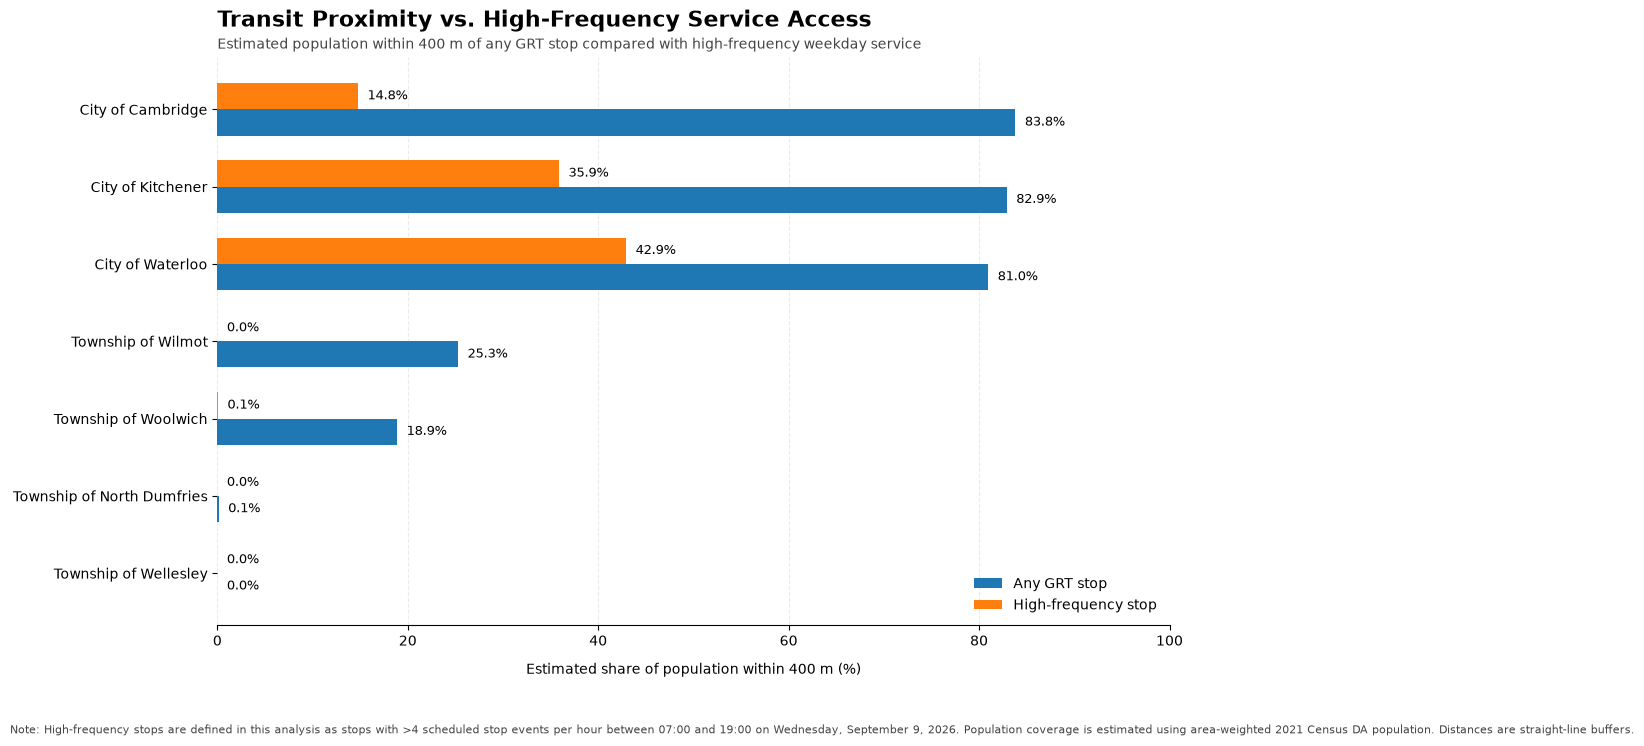

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path


# --------------------------------------------------
# Figure 4: Transit proximity vs. high-frequency access
# --------------------------------------------------

chart_data = municipality_comparison[
    [
        "FullName",
        "Pct_Any_Stop_400",
        "Pct_High_Frequency_400"
    ]
].copy()

# Sort so highest overall accessibility appears at the top
chart_data = chart_data.sort_values(
    "Pct_Any_Stop_400",
    ascending=True
)

y = np.arange(len(chart_data))
bar_height = 0.34


# --------------------------------------------------
# Create figure
# --------------------------------------------------

fig, ax = plt.subplots(figsize=(12, 7.5))


# --------------------------------------------------
# Draw bars
# --------------------------------------------------

bars_any = ax.barh(
    y - bar_height / 2,
    chart_data["Pct_Any_Stop_400"],
    height=bar_height,
    label="Any GRT stop"
)

bars_high = ax.barh(
    y + bar_height / 2,
    chart_data["Pct_High_Frequency_400"],
    height=bar_height,
    label="High-frequency stop"
)


# --------------------------------------------------
# Municipality labels
# --------------------------------------------------

ax.set_yticks(y)

ax.set_yticklabels(
    chart_data["FullName"],
    fontsize=10
)


# --------------------------------------------------
# Percentage labels
# --------------------------------------------------

for bar in bars_any:

    value = bar.get_width()

    ax.text(
        value + 1,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.1f}%",
        va="center",
        ha="left",
        fontsize=9
    )


for bar in bars_high:

    value = bar.get_width()

    ax.text(
        value + 1,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.1f}%",
        va="center",
        ha="left",
        fontsize=9
    )


# --------------------------------------------------
# Title and subtitle
# --------------------------------------------------

ax.set_title(
    "Transit Proximity vs. High-Frequency Service Access",
    fontsize=16,
    fontweight="bold",
    loc="left",
    pad=22
)

ax.text(
    0,
    1.015,
    "Estimated population within 400 m of any GRT stop compared with high-frequency weekday service",
    transform=ax.transAxes,
    fontsize=10,
    color="#444444"
)


# --------------------------------------------------
# Axis formatting
# --------------------------------------------------

ax.set_xlabel(
    "Estimated share of population within 400 m (%)",
    fontsize=10,
    labelpad=10
)

ax.set_xlim(0, 100)

ax.set_xticks(
    np.arange(0, 101, 20)
)

ax.grid(
    axis="x",
    linestyle="--",
    alpha=0.25
)

ax.set_axisbelow(True)


# --------------------------------------------------
# Remove unnecessary borders
# --------------------------------------------------

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)


# --------------------------------------------------
# Legend
# --------------------------------------------------

ax.legend(
    frameon=False,
    loc="lower right"
)


# --------------------------------------------------
# Methodology note
# --------------------------------------------------

fig.text(
    0.01,
    0.015,
    "Note: High-frequency stops are defined in this analysis as stops with >4 scheduled "
    "stop events per hour between 07:00 and 19:00 on Wednesday, September 9, 2026. "
    "Population coverage is estimated using area-weighted 2021 Census DA population. "
    "Distances are straight-line buffers.",
    fontsize=8,
    color="#444444"
)


# --------------------------------------------------
# Layout
# --------------------------------------------------

plt.tight_layout(
    rect=[0, 0.07, 1, 1]
)


# --------------------------------------------------
# Save figure
# --------------------------------------------------

figures_path = Path("../figures")

figures_path.mkdir(
    parents=True,
    exist_ok=True
)

plt.savefig(
    figures_path / "proximity_vs_frequency_access.png",
    dpi=300,
    bbox_inches="tight"
)


# --------------------------------------------------
# Display
# --------------------------------------------------

plt.show()